<a href="https://colab.research.google.com/github/raihan-uddinahmed/bioinformatics-basics/blob/main/notebooks/RNA_Seq_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Downloading the Dataset

In [ ]:
import pandas as pd
import requests
import os
import gzip


url = "https://www.ncbi.nlm.nih.gov/geo/download/?type=rnaseq_counts&acc=GSE128555&format=file&file=GSE128555_raw_counts_GRCh38.p13_NCBI.tsv.gz"
# url = "https://www.ncbi.nlm.nih.gov/geo/download/?type=rnaseq_counts&acc=GSE183947&format=file&file=GSE183947_raw_counts_GRCh38.p13_NCBI.tsv.gz"

# url = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE183947&format=file&file=GSE183947%5Ffpkm%2Ecsv%2Egz"


file_name = "GSE128555_raw_counts_GRCh38.p13_NCBI.tsv.gz"
# file_name = "GSE183947_fpkm.csv.gz"

if not os.path.exists(file_name):
   response = requests.get(url, stream = True)
   if response.status_code == 200:
    with open(file_name, 'wb') as f:
        f.write(response.content)
        # print(f"File downloaded: {file_name}")
   else:
        print(f"Failed to download the file. Status code: {response.status_code}")

# Loading the dataset as a Pandas Dataframe
df = pd.read_csv(file_name, sep='\t', compression = "gzip")
df.set_index(df.columns[0], inplace = True)

print(f"Total Count = {df.shape}")

# Cleaning the counts of the RNA_seq
df = df[df.sum(axis=1) >0]

print(f"Total Count after cleaning = {df.shape}")

Total Count = (39376, 9)
Total Count after cleaning = (28232, 9)


In [ ]:
df.head(10)

,GSM3679944,GSM3679945,GSM3679946,GSM3679947,GSM3679948,GSM3679949,GSM3679950,GSM3679951,GSM3679952
GeneID,,,,,,,,,
100287102,2,4,1,2,4,1,2,6,0
653635,358,512,387,454,522,369,291,735,244
102466751,5,8,11,5,10,2,9,16,3
107985730,3,1,1,2,2,1,1,1,0
100302278,1,0,0,0,0,0,0,1,0
645520,7,10,3,7,10,4,5,15,3
79501,0,0,1,1,1,0,0,0,1
100996442,11,14,20,12,24,24,5,30,16
729737,3,43,95,5,83,109,3,79,67


In [ ]:
import pandas as pd

# Creating the metadata dictionary
metadata_dict = {
    'GSM3679944': ['Control', 'Monosomal'],
    'GSM3679945': ['Control', 'Intermediate'],
    'GSM3679946': ['Control', 'Polysomal'],
    'GSM3679947': ['HIF1a_KD', 'Monosomal'],
    'GSM3679948': ['HIF1a_KD', 'Intermediate'],
    'GSM3679949': ['HIF1a_KD', 'Polysomal'],
    'GSM3679950': ['HIF2a_KD', 'Monosomal'],
    'GSM3679951': ['HIF2a_KD', 'Intermediate'],
    'GSM3679952': ['HIF2a_KD', 'Polysomal']
}

metadata = pd.DataFrame.from_dict(metadata_dict, orient='index', columns=['Treatment', 'Fraction'])
print(metadata)


           Treatment      Fraction
GSM3679944   Control     Monosomal
GSM3679945   Control  Intermediate
GSM3679946   Control     Polysomal
GSM3679947  HIF1a_KD     Monosomal
GSM3679948  HIF1a_KD  Intermediate
GSM3679949  HIF1a_KD     Polysomal
GSM3679950  HIF2a_KD     Monosomal
GSM3679951  HIF2a_KD  Intermediate
GSM3679952  HIF2a_KD     Polysomal


In [ ]:
!pip install pydeseq2

In [ ]:
import numpy as np
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats


# Transposing the count_dataframe
count_df = df.T


# all(count_df.index == metadata.index)

dds = DeseqDataSet(
    counts=count_df,
    metadata=metadata,
    design="~Treatment",
    refit_cooks=True,
    n_cpus=1
)

dds.deseq2()
stat_res = DeseqStats(
    dds,
    contrast=["Treatment", "HIF1a_KD", "Control"]
)

stat_res.summary()

/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 55.58 seconds.

Fitting dispersion trend curve...
... done in 0.70 seconds.

Fitting MAP dispersions...
... done in 66.89 seconds.

Fitting LFCs...
... done in 33.12 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 11.51 seconds.



Log2 fold change & Wald test p-value: Treatment HIF1a_KD vs Control
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
GeneID                                                                   
100287102       2.506849       -0.309387  1.409208 -0.219547  0.826224   
653635        446.002552       -0.137826  0.674347 -0.204385  0.838053   
102466751       7.990671       -0.653874  0.989929 -0.660526  0.508916   
107985730       1.754229       -0.482739  1.553755 -0.310692  0.756035   
100302278       0.287770       -1.314166  4.440069 -0.295979  0.767246   
...                  ...             ...       ...       ...       ...   
4541        58789.531051        0.240583  1.116488  0.215482  0.829391   
4556         4678.839286        0.130486  1.167292  0.111785  0.910994   
4519       341175.142282       -0.101425  1.265518 -0.080145  0.936122   
4576         1028.741430        0.388503  1.252942  0.310072  0.756506   
4571        14804.930752        0.340711  1.

In [ ]:
dds.var

,_normed_means,non_zero,_MoM_dispersions,genewise_dispersions,_genewise_converged,fitted_dispersions,MAP_dispersions,_MAP_converged,dispersions,_outlier_genes,_LFC_converged,replaced,refitted,_pvalue_cooks_outlier
GeneID,,,,,,,,,,,,,,
100287102,2.506849,True,1.000000e-08,1.000000e-08,True,2.050471,0.999823,True,0.999823,False,True,False,False,False
653635,446.002552,True,2.221348e-01,2.841360e-01,True,0.488374,0.325375,True,0.325375,False,True,False,False,False
102466751,7.990671,True,2.146470e-01,4.023730e-01,True,0.972378,0.547677,True,0.547677,False,True,False,False,False
107985730,1.754229,True,1.295372e-01,6.168213e-01,True,2.724448,1.201759,True,1.201759,False,True,False,False,False
100302278,0.287770,True,1.000000e-08,1.000000e-08,True,14.164337,10.000000,True,10.000000,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4541,58789.531051,True,7.762478e-01,1.038238e+00,True,0.479611,0.898343,True,0.898343,False,True,False,False,False
4556,4678.839286,True,8.470163e-01,1.151948e+00,True,0.480386,0.981738,True,0.981738,False,True,False,False,False
4519,341175.142282,True,8.382941e-01,1.389613e+00,True,0.479555,1.154193,True,1.154193,False,True,False,False,False


## Volcano Plot

/tmp/ipykernel_5178/3038016304.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['neg_log10_pvalue'] = -np.log10(results['pvalue'])
/tmp/ipykernel_5178/3038016304.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Significance'] = 'Not significant'


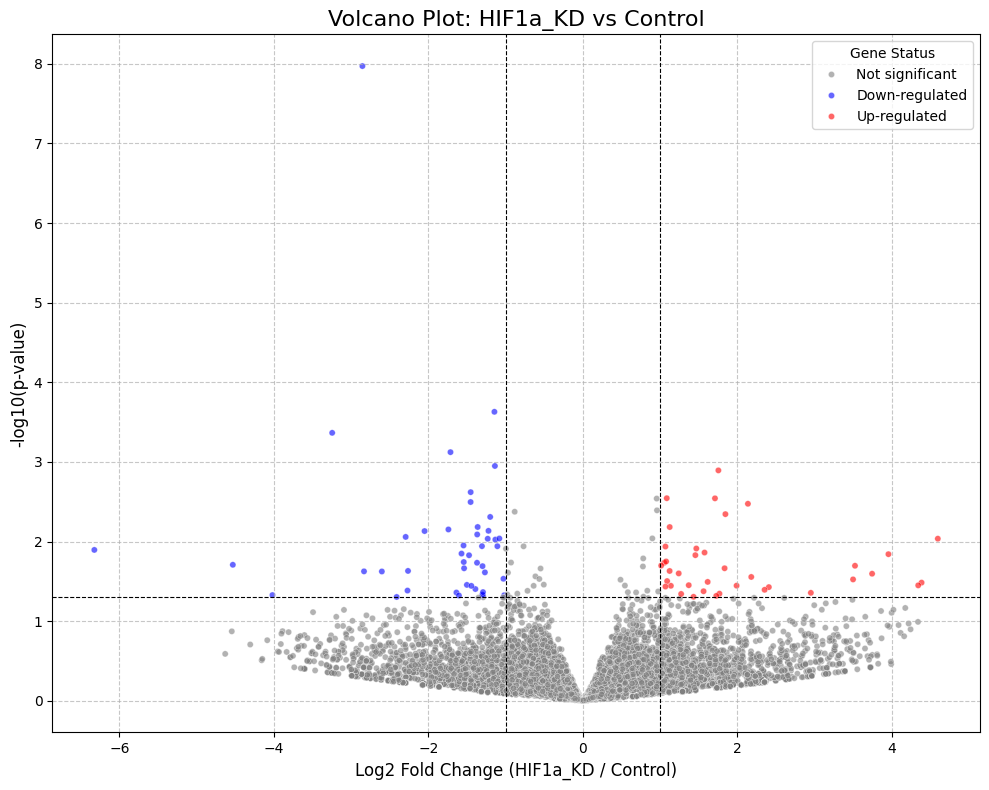

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get the results from stat_res.summary()
results = stat_res.results_df


results = results.dropna(subset=['pvalue', 'log2FoldChange'])

# Calculate -log10(pvalue)
results['neg_log10_pvalue'] = -np.log10(results['pvalue'])


alpha = 0.05  # p-value threshold
log2fc_threshold = 1 # log2 fold change threshold


results['Significance'] = 'Not significant'
results.loc[(results['pvalue'] < alpha) & (results['log2FoldChange'] > log2fc_threshold), 'Significance'] = 'Up-regulated'
results.loc[(results['pvalue'] < alpha) & (results['log2FoldChange'] < -log2fc_threshold), 'Significance'] = 'Down-regulated'


plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='log2FoldChange',
    y='neg_log10_pvalue',
    hue='Significance',
    palette={'Up-regulated': 'red', 'Down-regulated': 'blue', 'Not significant': 'gray'},
    data=results,
    alpha=0.6,
    s=20
)


plt.axvline(x=log2fc_threshold, color='black', linestyle='--', linewidth=0.8)
plt.axvline(x=-log2fc_threshold, color='black', linestyle='--', linewidth=0.8)
plt.axhline(y=-np.log10(alpha), color='black', linestyle='--', linewidth=0.8)

plt.title('Volcano Plot: HIF1a_KD vs Control', fontsize=16)
plt.xlabel('Log2 Fold Change (HIF1a_KD / Control)', fontsize=12)
plt.ylabel('-log10(p-value)', fontsize=12)
plt.legend(title='Gene Status')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Cluster Heatmap

In [ ]:
dds.layers["log1p"] = np.log1p(dds.layers["normed_counts"])
sig_gene = results.loc[(results['pvalue'] < alpha) & (results['log2FoldChange'] > log2fc_threshold)]
dds_sigs = dds[:, sig_gene.index]

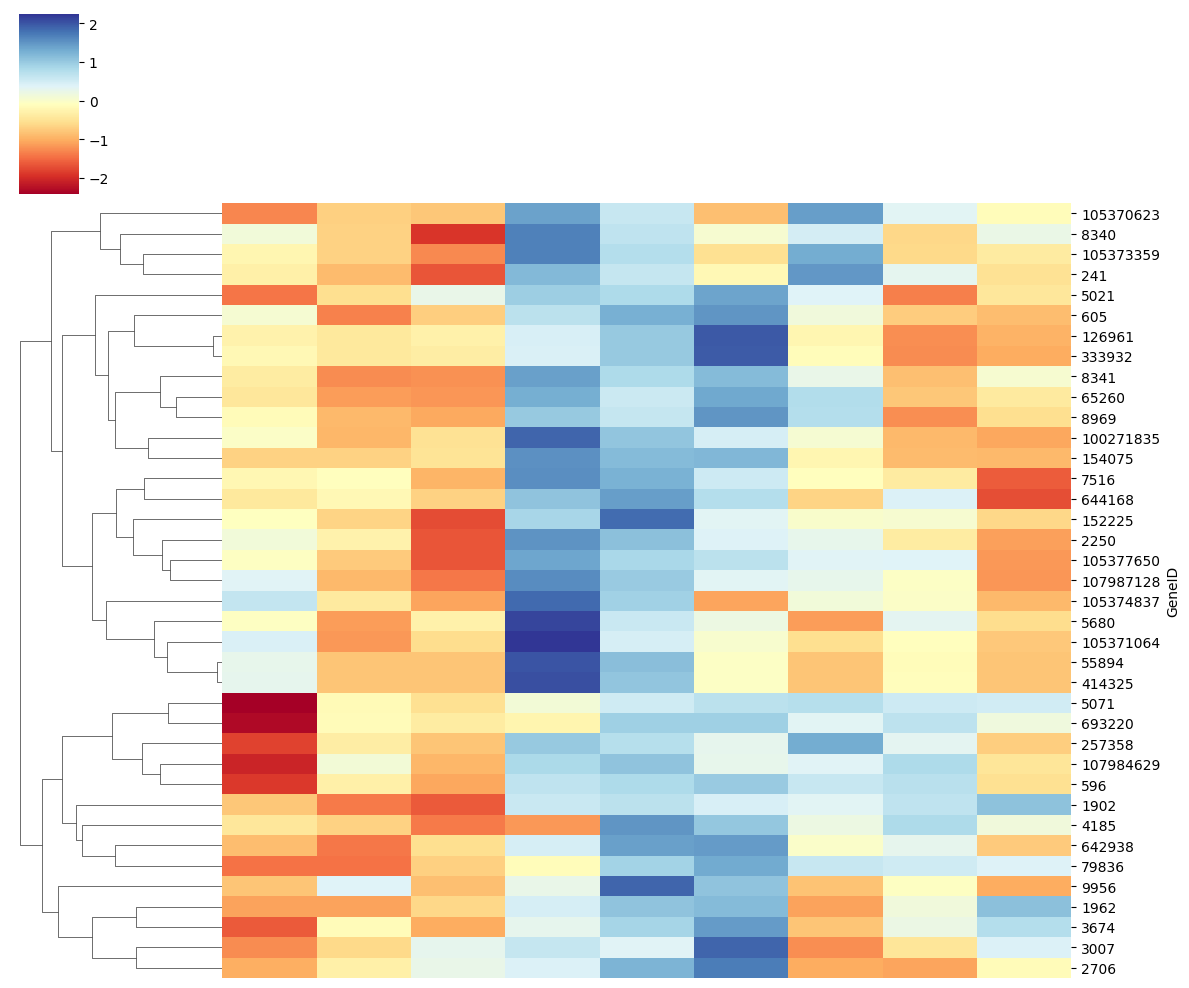

In [ ]:
grapher = pd.DataFrame(
    dds_sigs.layers["log1p"].T,
    index=dds_sigs.var_names,
    columns=dds_sigs.obs_names
)
sns.clustermap(
    grapher,
    cmap = "RdYlBu",
    col_cluster=False,
    xticklabels=False,
    yticklabels=True,
    figsize=(12, 10),
    z_score=0
)